In [1]:
import pickle

# Open the pickle file in binary read mode
with open('gradient_test_unclear_gradient_exponax_nu0.0005.pkl', 'rb') as file:
    # Load the data from the pickle file
    data = pickle.load(file)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gradient_delta_metrics(data, title_suffix=""):
    # Extract the steps and metrics
    steps = sorted([int(step.split('_')[1]) for step in data.keys()])[1:]
    
    # Initialize lists to store metrics
    grad_with_solver = []
    grad_detached = []
    grad_approximated = []
    
    delta_with_solver = []
    delta_detached = []
    delta_approximated = []
    
    ratio_with_solver = []
    ratio_detached = []
    ratio_approximated = []

    for step in sorted(data.keys(), key=lambda x: int(x.split('_')[1]))[1:]:
        step_data = data[step]
        
        # Gradient norms
        grad_with_solver.append(step_data['grad_metrics']['withsolver_vs_detached']['gradient_with_solver_norm'])
        grad_detached.append(step_data['grad_metrics']['withsolver_vs_detached']['gradient_detached_norm'])
        grad_approximated.append(step_data['grad_metrics']['withsolver_vs_approximated']['gradient_approximated_norm'])
        
        # Delta norms
        delta_with_solver.append(step_data['delta_metrics']['withsolver_vs_detached']['delta_with_solver_norm'])
        delta_detached.append(step_data['delta_metrics']['withsolver_vs_detached']['delta_detached_norm'])
        delta_approximated.append(step_data['delta_metrics']['withsolver_vs_approximated']['delta_approximated_norm'])
        
        # Calculate ratios
        ratio_with_solver.append(grad_with_solver[-1] / delta_with_solver[-1])
        ratio_detached.append(grad_detached[-1] / delta_detached[-1])
        ratio_approximated.append(grad_approximated[-1] / delta_approximated[-1])

    # Create the plots
    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Gradient and Delta Metrics {title_suffix}", y=1.05)

    # Gradient Norms plot
    plt.subplot(1, 4, 1)
    plt.plot(steps, grad_with_solver, label='With Solver', linestyle='-')
    plt.plot(steps, grad_detached, label='Detached', linestyle='-')
    plt.plot(steps, grad_approximated, label='Approximated', linestyle='-')
    plt.xlabel('Step Number')
    plt.ylabel('Gradient Norm')
    plt.title('Gradient Norms')
    plt.legend()
    plt.grid(True)

    # Delta Norms plot
    plt.subplot(1, 4, 2)
    plt.plot(steps, delta_with_solver, label='With Solver', linestyle='-')
    plt.plot(steps, delta_detached, label='Detached', linestyle='-')
    plt.plot(steps, delta_approximated, label='Approximated', linestyle='-')
    plt.xlabel('Step Number')
    plt.ylabel('Delta Norm')
    plt.title('Delta Norms')
    plt.legend()
    plt.grid(True)

    # Ratio plot
    plt.subplot(1, 4, 3)
    plt.plot(steps, ratio_with_solver, label='With Solver', linestyle='-')
    plt.plot(steps, ratio_detached, label='Detached', linestyle='-')
    plt.plot(steps, ratio_approximated, label='Approximated', linestyle='-')
    plt.xlabel('Step Number')
    plt.ylabel('Gradient Norm / Delta Norm')
    plt.title('Gradient-Delta Norm Ratio')
    plt.legend()
    plt.grid(True)

    # New plot: Gradient ratios
    plt.subplot(1, 4, 4)
    plt.plot(steps, np.array(grad_with_solver)/np.array(grad_detached), 
            label='With Solver / Detached', linestyle='-')
    plt.plot(steps, np.array(grad_with_solver)/np.array(grad_approximated), 
            label='With Solver / Approximated', linestyle='-')
    plt.xlabel('Step Number')
    plt.ylabel('Ratio')
    plt.title('Gradient Norm Ratios')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()  # Adjust spacing between subplots
    plt.show()

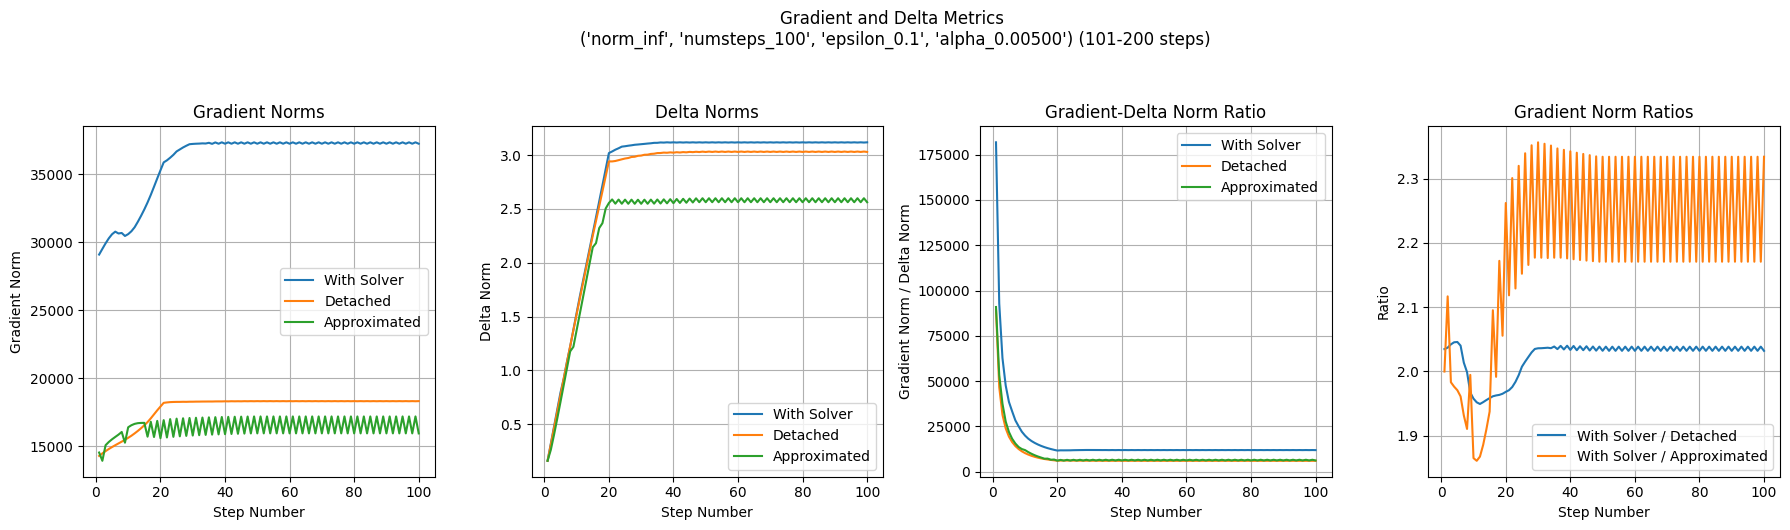

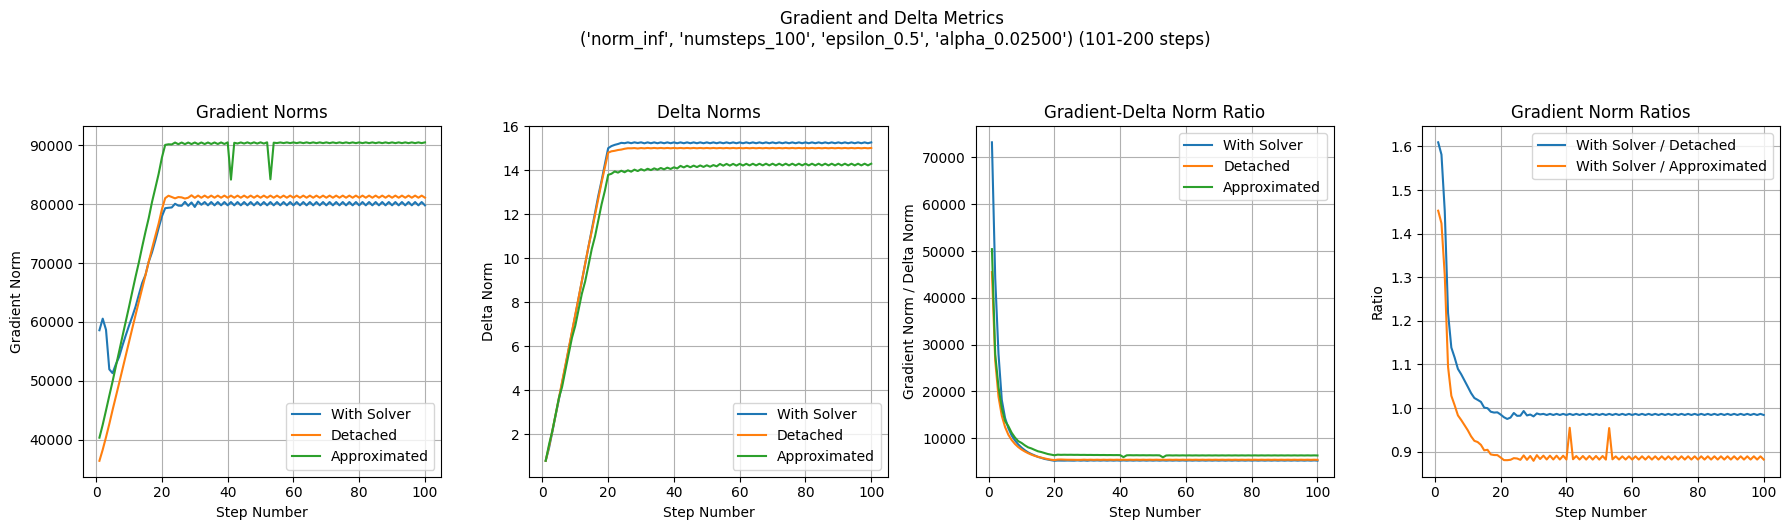

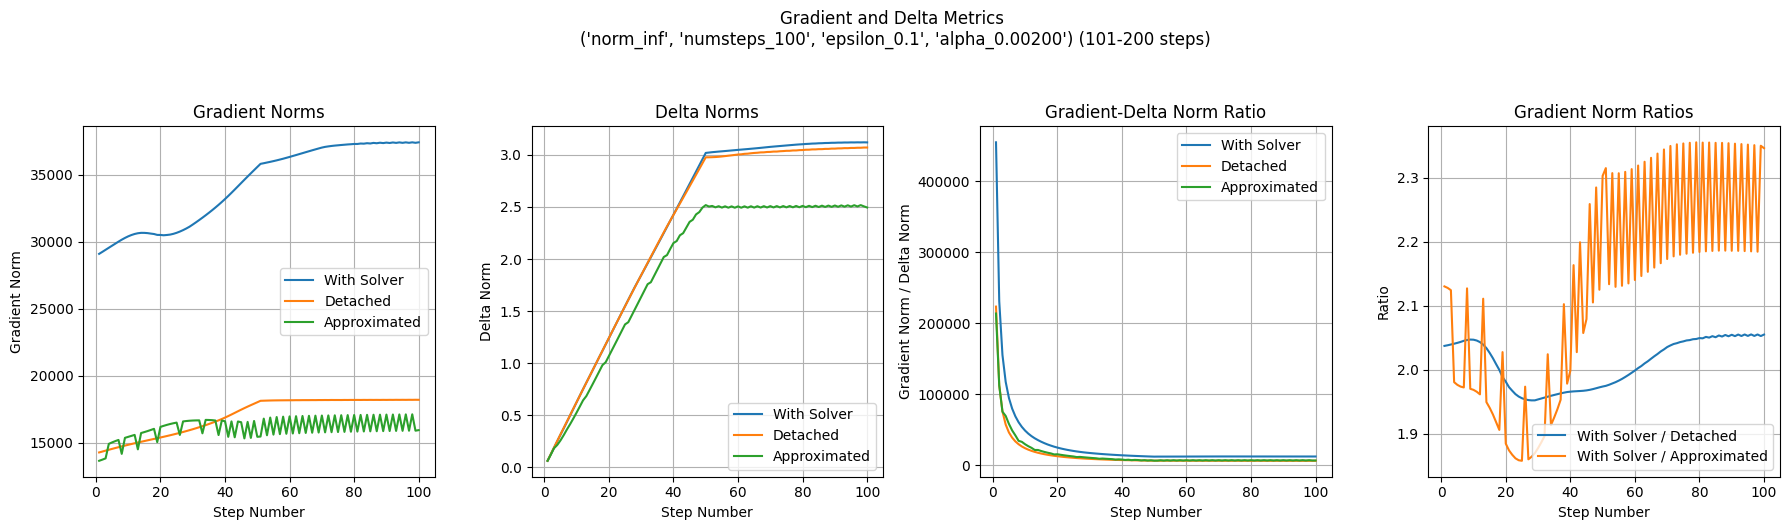

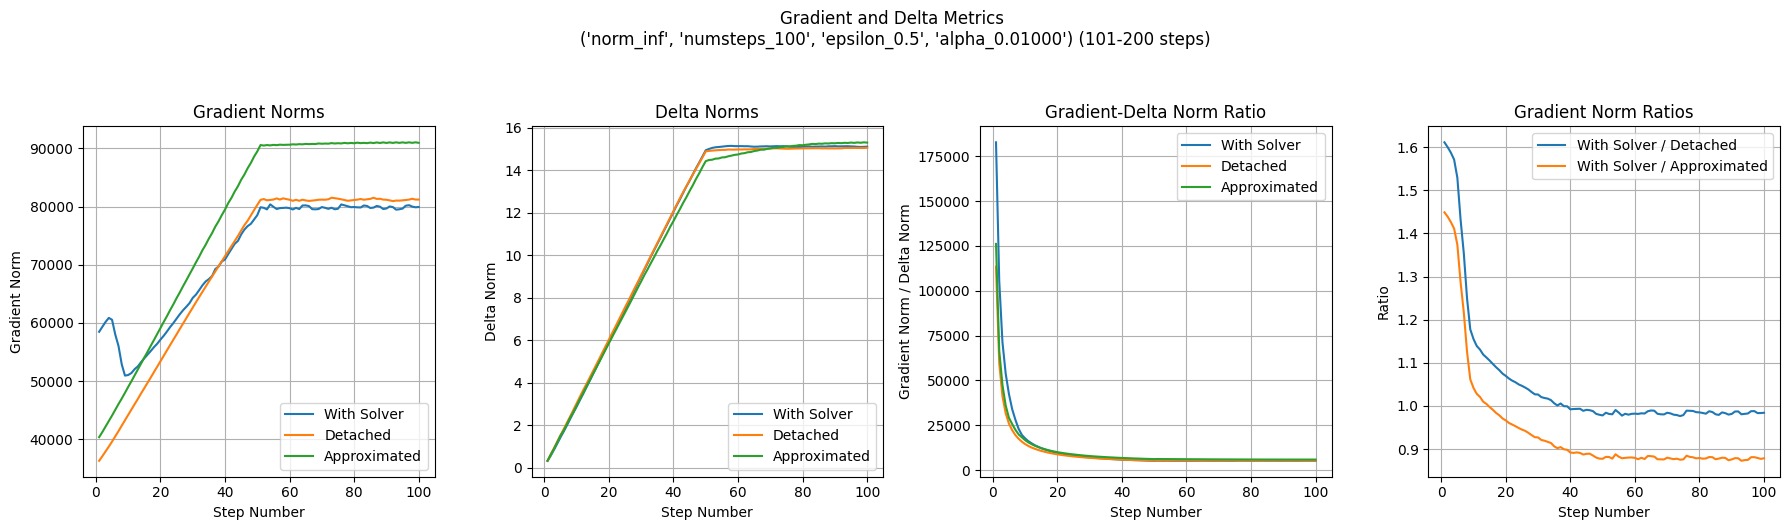

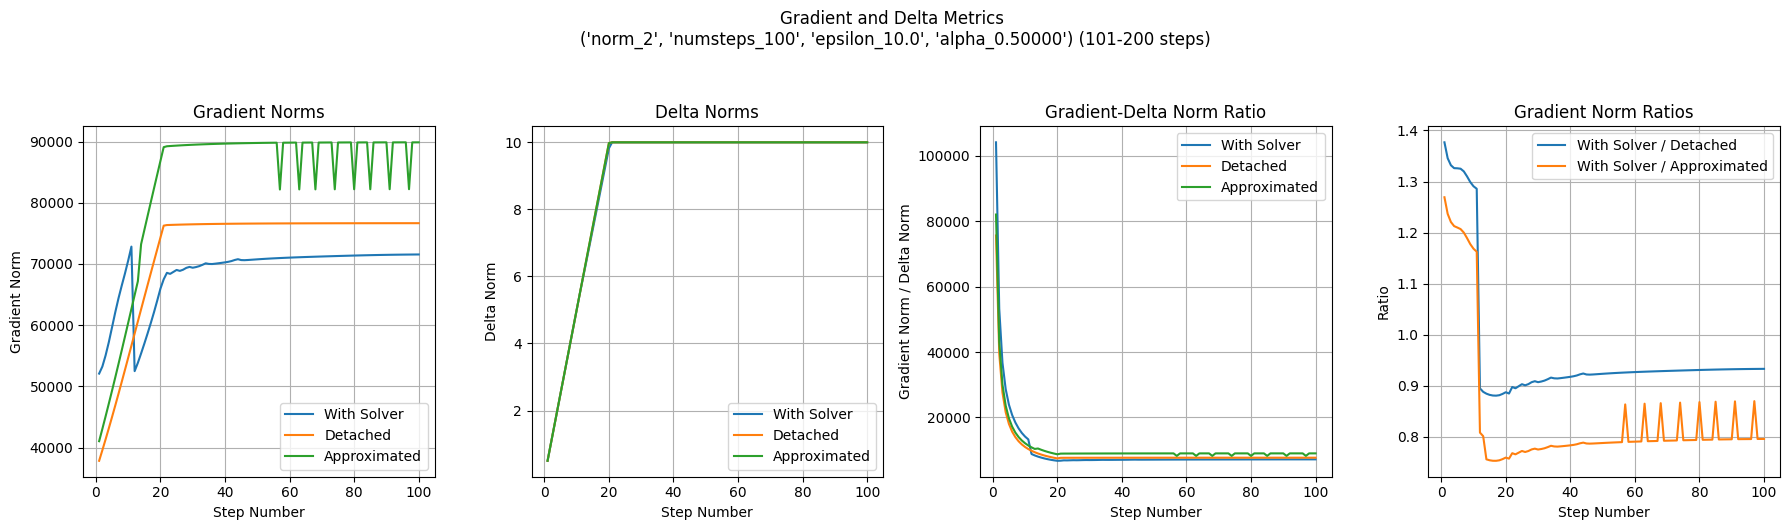

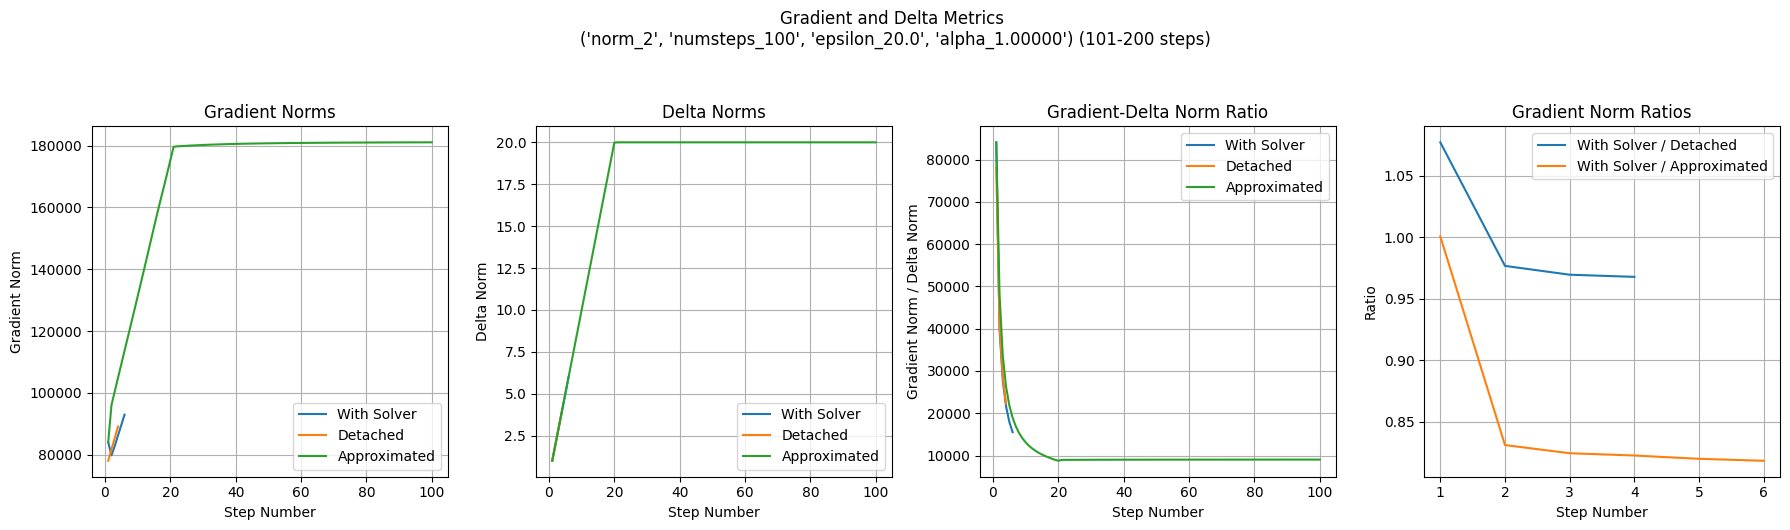

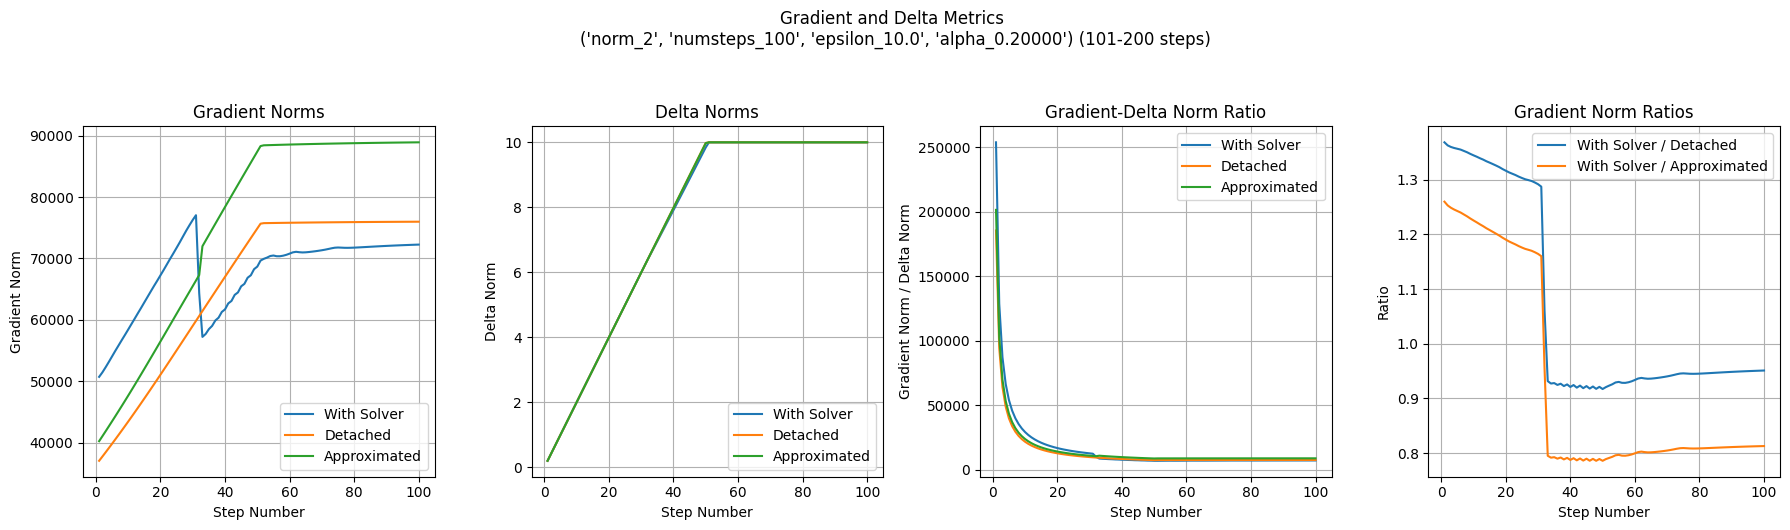

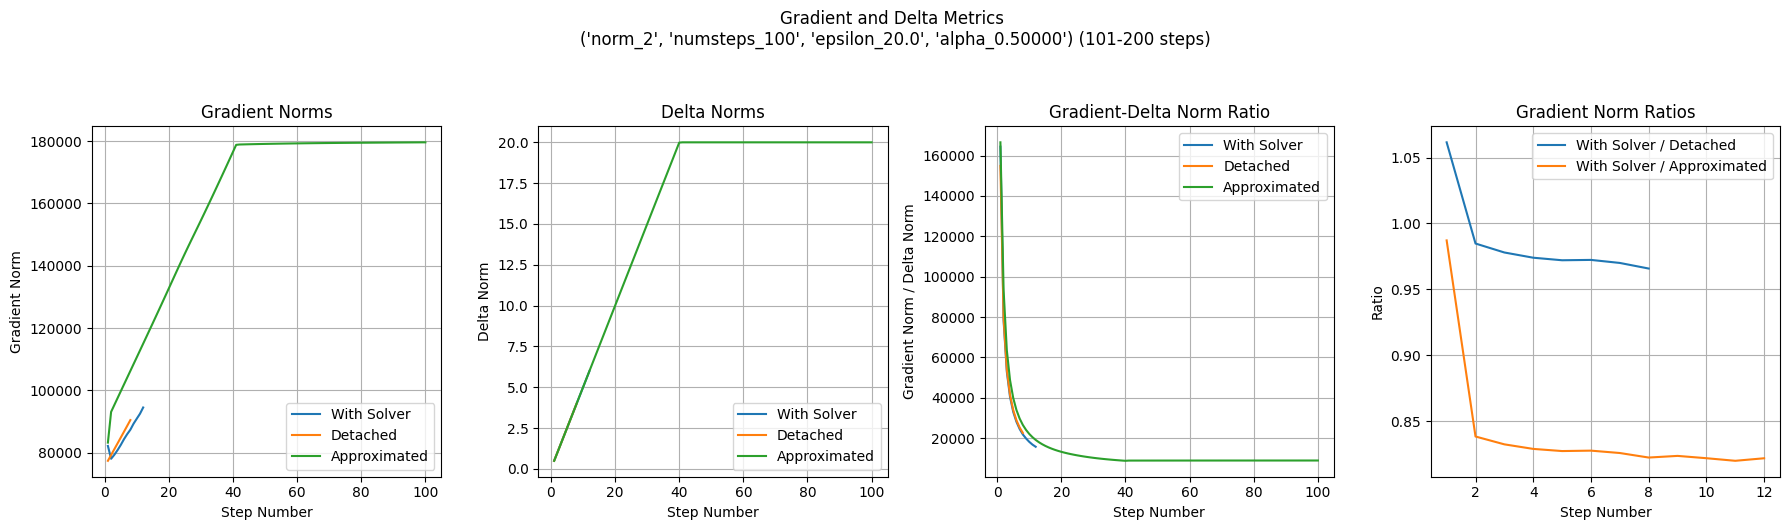

In [4]:
for key in data.keys():
    plot_gradient_delta_metrics(data[key]['step_update'], 
                            title_suffix=f"\n{key} (101-200 steps)")

In [8]:
data[key]['step_update']

{'step_0': {'loss_metrics': {'with_solver': 68847.45521846812,
   'without_solver': 68847.45521846812,
   'approximate': 68847.45521846812}},
 'step_1': {'reaches_boundary': {'with_solver': 0.0,
   'detached': 0.0,
   'approximated': 0.0},
  'grad_metrics': {'withsolver_vs_detached': {'gradient_with_solver_length': 1024,
    'gradient_detached_length': 1024,
    'gradient_with_solver_norm': 20802.404125741756,
    'gradient_detached_norm': 10416.596520079247,
    'norm_ratio': 1.9970442443117202,
    'rmse': 325.1334064145291,
    'ame': 266.889297247248,
    'pme': 49.80544402325842,
    'cosine_similarity': 0.9991143719864516,
    'angle_degrees': 2.4115449428686895,
    'sign_agreement_percentage': 99.51171875},
   'withsolver_vs_approximated': {'gradient_with_solver_length': 1024,
    'gradient_approximated_length': 1024,
    'gradient_with_solver_norm': 20802.404125741756,
    'gradient_approximated_norm': 10540.19846501358,
    'norm_ratio': 1.9736254677548857,
    'rmse': 329.93

In [3]:
data[('norm_inf',
  'index_0',
  'numsteps_100',
  'epsilon_0.1',
  'alpha_0.00500')]

{'step_update': {'step_0': {'loss_metrics': {'with_solver': 68847.45521846812,
    'without_solver': 68847.45521846812,
    'approximate': 68847.45521846812}},
  'step_1': {'reaches_boundary': {'with_solver': 0.0,
    'detached': 0.0,
    'approximated': 0.0},
   'grad_metrics': {'withsolver_vs_detached': {'gradient_with_solver_length': 1024,
     'gradient_detached_length': 1024,
     'gradient_with_solver_norm': 20802.404125741756,
     'gradient_detached_norm': 10416.596520079247,
     'norm_ratio': 1.9970442443117202,
     'rmse': 325.1334064145291,
     'ame': 266.889297247248,
     'pme': 49.80544402325842,
     'cosine_similarity': 0.9991143719864516,
     'angle_degrees': 2.4115449428686895,
     'sign_agreement_percentage': 99.51171875},
    'withsolver_vs_approximated': {'gradient_with_solver_length': 1024,
     'gradient_approximated_length': 1024,
     'gradient_with_solver_norm': 20802.404125741756,
     'gradient_approximated_norm': 10540.19846501358,
     'norm_ratio': 1